In [1]:
from typing_extensions import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

In [ ]:
!pip install langchain

In [6]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
)

In [8]:
from typing import TypedDict

class State(TypedDict):
    query:str
    category:str
    sentiment:str
    response:str

llm.invoke("what is langchain in 20 words?")     

AIMessage(content='<think>\nOkay, the user is asking for a 20-word explanation of LangChain. Let me start by recalling what LangChain is. It\'s a framework for building applications with large language models. I need to mention its key features like modularity, integration with various models, and tools for data handling. Also, it\'s used for creating chatbots, agents, and more. Let me check if I can condense that into 20 words without losing the main points. Maybe start with "LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots." Let me count the words. That\'s 20. It covers the main aspects: framework, purpose, key features, and applications. I think that works.\n</think>\n\nLangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 196, 'prompt_tokens': 18, 'total

In [9]:
def categorize(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        "Categorize the following query into one of the following categories: "
        "Technical, Billing, General. Query: {query}"
    )
    chain = prompt | llm
    category = chain.invoke({"query": state["query"]}).content
    print(f"\nCategory : {category}")
    return {"category": category}


def analyze_sentiment(state: State) -> State:
    print("\nAnalyzing the sentiment : ")
    prompt = ChatPromptTemplate.from_template(
        "Analyze the sentiment of the following customer query and ans in word "
        "Response with either 'Positive', 'Neutral', or 'Negative'. Query: {query}"
    )
    chain = prompt | llm
    sentiment = chain.invoke({"query": state["query"]}).content
    print(f"\nSentiment : {sentiment}")
    return {"sentiment": sentiment}


def handle_technical(state: State) -> State:
    print("\nHandling the technical query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a technical support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_billing(state: State) -> State:
    print("\nHandling the billing query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a billing support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_general(state: State) -> State:
    print("\nHandling the general query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a general support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def escalate(state: State) -> State:
    print("Escalating Query")
    return {
        "response": "This query has been escalate to a human agent due to its negative sentiment"
    }
    
def route_query(state: State) -> str:  # Changed from State to str
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"

In [10]:
workflow = StateGraph(State)

workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

workflow.set_entry_point("categorize")

workflow.add_edge("categorize", "analyze_sentiment")

# Add conditional edges with explicit paths
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    ["escalate", "handle_technical", "handle_billing", "handle_general"]
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

app = workflow.compile()

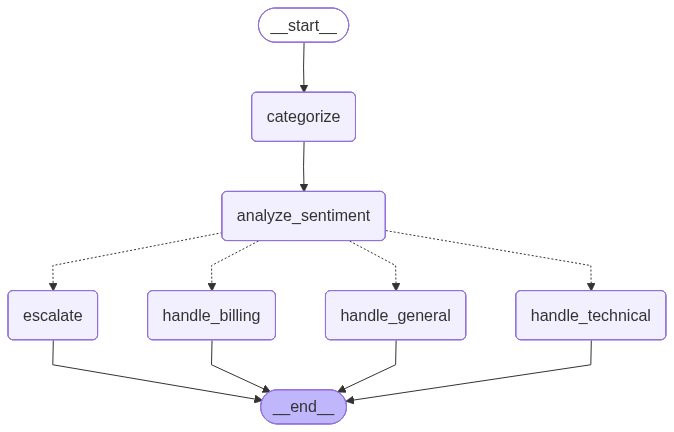

In [11]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

In [12]:
def run_customer_support(query: str) -> Dict[str, str]:
    results = app.invoke({"query": query})
    return {
        "category": results["category"],
        "sentiment": results["sentiment"],
        "response": results["response"]
    }

In [13]:
query = "The price value in my invoice is wrong"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : <think>
Okay, let's see. The user's query is "The price value in my invoice is wrong." I need to categorize this into Technical, Billing, or General.

First, I'll break down the query. The user is talking about an invoice and the price being incorrect. Invoices are related to billing, right? So if there's an issue with the amount charged or the price listed, that's a billing concern. Technical issues usually involve software, systems, or technical support problems. General might be for other non-specific issues.

But wait, could there be a technical reason for the wrong price? Like maybe a system error caused the invoice to show the wrong amount. However, the user is pointing out the price is wrong, not that the system is malfunctioning. They might just need a correction in the billing details. So the primary category here is likely Billing. Technical would be if there was a system error causing the issue, but the user is reporting the symptom, not the cause. So the answer 

In [14]:
query = "my iphone isnt working"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : <think>
Okay, let's see. The user's query is "my iphone isnt working." I need to categorize this into Technical, Billing, or General.

First, I'll consider what each category means. Technical issues usually involve problems with the device's functionality, like hardware or software issues. Billing relates to payment, invoices, or subscription problems. General might be about account issues, service inquiries, or other non-technical/billing topics.

The user is saying their iPhone isn't working. That sounds like a problem with the device itself—maybe it's not turning on, has software glitches, or hardware failure. There's no mention of payment or billing here. They're not talking about a service plan or charges. So it's probably not Billing. General could be if they were asking about features or account setup, but the issue here is the device not working. So Technical seems the right category. I should make sure there's no ambiguity. If they had said something like "my iPhon

In [15]:
query = "I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : <think>
Okay, let's see. The user bought an iPhone 16 and the screen is broken. They're saying it's not the service they expected. Hmm. So first, I need to figure out which category this falls into: Technical, Billing, or General.

Technical issues usually relate to product functionality, like hardware problems or software glitches. Billing is about payments, invoices, or charges. General might be other concerns like customer service, product quality, or service expectations.

The user is complaining about a broken screen on a newly purchased phone. That sounds like a product defect or quality issue. They mention it's not the service they expected, which could relate to the product's condition upon delivery. So, is this a technical problem? Well, the screen being broken is a hardware issue, which is technical. But they're also talking about the service experience, which might be more general. However, since the main issue is the broken screen, which is a technical defect, m

In [16]:
query = "I am really happy with the service and I want invoice for my new purchase"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : <think>
Okay, let's see. The user wrote, "I am really happy with the service and I want invoice for my new purchase." I need to categorize this into Technical, Billing, or General.

First, the first part is about being happy with the service. That's a positive comment, but the main request is for an invoice. Invoices are related to billing because they deal with payment and financial transactions. Technical issues would be about software, hardware, or technical support. General might be about account information, service inquiries, etc. Since the user is asking for an invoice, which is a billing document, this should be categorized under Billing. The initial comment about being happy is just a positive note but doesn't change the category. So the answer is Billing.
</think>

The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service i

In [17]:
query = "When is the new iphone will launching?"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : <think>
Okay, let's see. The user is asking, "When is the new iPhone will launching?" First, I need to figure out which category this falls into: Technical, Billing, or General.

Technical questions usually relate to the product's features, specifications, or how to use it. Billing is about payments, invoices, or subscription issues. General would be other inquiries that don't fit into the first two, like events, availability, or company news.

The query is about the launch date of a new iPhone. That's about when the product will be available, not about technical specs or billing. So it's probably a General question. But wait, sometimes product launches can be considered technical if they're about the product's features. But in this case, the user is specifically asking about the timing, which is more about availability and company announcements. So General makes sense here. I should check if there's any overlap. Maybe if they asked about the features, it would be technical